<a href="https://colab.research.google.com/github/updalla-apshir/machine-learning-projects/blob/main/Building_Linear_Regression_from_scratch_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Linear Regression:

**Y = wX + b**

Y --> Dependent Variable

X --> Independent Variable

w --> weight

b --> bias

**Gradient Descent:**

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

w  =  w - α*dw

b  =  b - α*db

**Learning Rate:**

Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.

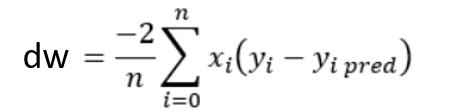

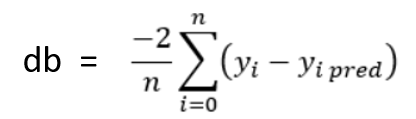

In [ ]:
## importing numpy library
import numpy as np

## **Linear Regression**

In [ ]:
class LinearRegression():
  #hyperparameters
  def __init__(self, learning_rate, no_of_iterations):
    self.learning_rate = learning_rate
    self.no_of_iterations = no_of_iterations

  def fit(self, X, Y):

    self.m, self.n = X.shape

    # the weight and bias
    self.w = np.zeros(self.n)
    self.b = 0
    self.X = X
    self.Y = Y

    for i in range(self.no_of_iterations):
      self.update_weights()
  def update_weights(self):
     Y_prediction = self.predict(self.X)

     # calculate gradients
     dw = - (2 * (self.X.T).dot(self.Y - Y_prediction) ) / self.m
     db = - 2 * np.sum(self.Y - Y_prediction) / self.m

     # upadating the weights
     self.w = self.w - self.learning_rate * dw
     self.b = self.b - self.learning_rate * db


  def predict(self,X):
    return X.dot(self.w) + self.b


**using our linear regression model**

In [ ]:
# importing the dependecies
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score,accuracy_score,mean_squared_error



**data preprocessing**

In [ ]:
# Load the bodyfat dataset
body_fat = fetch_openml(
    name="bodyfat",
    version=1,
    as_frame=True
)




In [ ]:
body_fat_df = pd.DataFrame(body_fat.data,columns=body_fat.feature_names)


In [ ]:
body_fat_df['Outcome'] = body_fat.target

In [ ]:
# printing the dataset
body_fat_df

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,Outcome
0,1.0708,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1,12.3
1,1.0853,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2,6.1
2,1.0414,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6,25.3
3,1.0751,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2,10.4
4,1.0340,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7,28.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,1.0736,70,134.25,67.00,34.9,89.2,83.6,88.8,49.6,34.8,21.5,25.6,25.7,18.5,11.0
248,1.0236,72,201.00,69.75,40.9,108.5,105.0,104.5,59.6,40.8,23.2,35.2,28.6,20.1,33.6
249,1.0328,72,186.75,66.00,38.9,111.1,111.5,101.7,60.3,37.3,21.5,31.3,27.2,18.0,29.3
250,1.0399,72,190.75,70.50,38.9,108.3,101.3,97.8,56.0,41.6,22.7,30.5,29.4,19.8,26.0


In [ ]:
# inspect the data
body_fat_df.describe()

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,Outcome
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762,19.150794
std,0.019031,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585,8.368740
min,0.995000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000,0.000000
25%,1.041400,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000,12.475000
50%,1.054900,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000,19.200000
75%,1.070400,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000,25.300000
max,1.108900,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000,47.500000


In [ ]:
# checking missing values
body_fat_df.isnull().sum()

,0
Density,0
Age,0
Weight,0
Height,0
Neck,0
Chest,0
Abdomen,0
Hip,0
Thigh,0
Knee,0


In [ ]:
body_fat_df.shape

(252, 15)

In [ ]:
# separate features and targets
X = body_fat_df.drop('Outcome', axis=1)
Y = body_fat_df['Outcome']

In [ ]:
# split into training and testing
X_train,X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=2)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(201, 14)
(51, 14)


In [ ]:
# feature scaling
scaler = StandardScaler()

In [ ]:
# Fit scaler ONLY on training data
scaler.fit(X_train)

StandardScaler()

In [ ]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

training our LinearRegression model

In [ ]:
model = LinearRegression(learning_rate=0.01,no_of_iterations=1000)

In [ ]:
model.fit(X_train,Y_train)

In [ ]:
# printing the parameters (weight & bias)

print('weight: ', model.w[0])
print('bias: ', model.b)

weight:  -7.5964722524381285
bias:  19.4004974797874


predict the test data

In [ ]:
test_data_prediction = model.predict(X_test)


In [ ]:
print(test_data_prediction)

[14.60022869 18.47602515 24.91754675 15.42582919 26.28267935 33.05420651
 13.39048401 11.70226133 39.06987803 21.56671702  7.35661521 16.77684832
 12.90054491 11.38678422 18.52577175 10.72868325 -4.08606487  9.85494196
 12.41136906 20.90777085 27.24816947 23.40907807 21.0305827  13.02536276
 25.08838171 30.43137213  3.91099165 16.31190233 19.37929833 20.67985497
 21.52628624 21.05430489 30.2459569  26.84783778  7.95212147 22.23528694
 15.32933337 16.7804571   6.36055942 10.52633378 22.07041376 21.40732524
 20.93708346 15.00220583 24.58417942 25.31991462 26.68395084  3.73000437
 15.39350438 22.44116978 12.08141363]


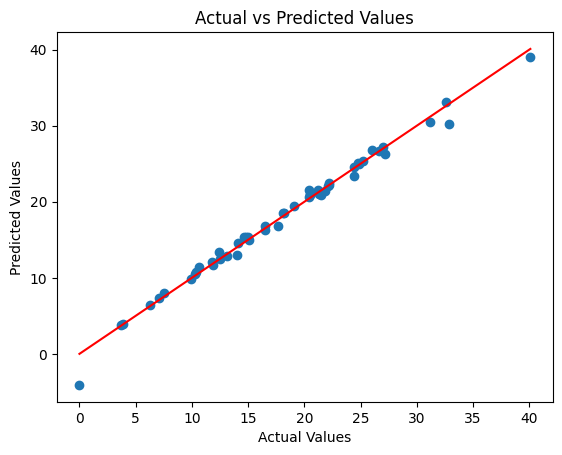

In [ ]:
plt.scatter(Y_test, test_data_prediction)

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    color='red'
)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')

plt.show()

In [ ]:
train_prediction = model.predict(X_train)

print("Train R2:", r2_score(Y_train, train_prediction))
print("Test R2:", r2_score(Y_test, test_data_prediction))
accuracy_percentage = r2_score(Y_test, test_data_prediction) * 100

print(f"accuracy percentage: {accuracy_percentage:.2f}%")

Train R2: 0.9743492585530825
Test R2: 0.9889265601492445
accuracy percentage: 98.89%


## Making Predictive System

In [ ]:
input = (1.0506, 49.0, 198.5, 73.5, 40.1, 106.5, 95.0, 101.7, 59.0, 39.4, 22.3, 32.2, 31.0, 18.6)

input_df = pd.DataFrame([input], columns=X.columns)


std_data = scaler.transform(input_df)

prediction = model.predict(std_data)

predicted_class = (prediction[0])

print(predicted_class)



21.664082891140616


printing the correct value and input data before predicting

In [ ]:
values = X.iloc[100]
print(', '.join(map(str,values)))

1.0506, 49.0, 198.5, 73.5, 40.1, 106.5, 95.0, 101.7, 59.0, 39.4, 22.3, 32.2, 31.0, 18.6


In [ ]:
print(Y.iloc[100])

21.2
